In [ ]:
#!pip install tensorflow
#!pip install pydot
#!pip install graphviz


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [14]:
image_size = (180, 180)
batch_size = 16

#split images into train and test directories
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/Users/narit/Desktop/allenislandtrash/train",
    seed=543543,
    image_size=image_size,
    batch_size=batch_size,
)

Found 294 files belonging to 2 classes.


In [15]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/Users/narit/Desktop/allenislandtrash/test",
    seed=543543,
    image_size=image_size,
    batch_size=batch_size,
)

Found 41 files belonging to 2 classes.


In [23]:
for images, labels in train_ds.unbatch().take(1):  # only take first element of dataset
    x_test = images.numpy()
    y_test = labels.numpy()
    print(y_test)

0


In [24]:
print(x_test)

[[[192.93668  198.49333  189.82333 ]
  [177.61331  176.61331  172.61331 ]
  [122.11667  133.8      130.53334 ]
  ...
  [154.55     123.1       83.916664]
  [169.00684  140.23978   99.47975 ]
  [ 92.63626   87.03665   80.43704 ]]

 [[179.58     186.38     179.48001 ]
  [217.15001  223.95     217.05    ]
  [155.25     156.35     153.8     ]
  ...
  [156.65001  128.40001   92.850006]
  [161.58969  148.58969  131.58969 ]
  [ 98.80019   90.33984   81.86963 ]]

 [[154.26666  155.26666  149.26666 ]
  [193.53334  196.53334  189.33334 ]
  [193.08333  194.74998  189.58333 ]
  ...
  [199.41667  199.41667  172.25    ]
  [173.46631  167.71655  151.63315 ]
  [166.66602  157.66602  148.66602 ]]

 ...

 [[134.66704  133.96704  112.06705 ]
  [ 67.88328   69.88318   55.799854]
  [ 95.33325   99.33325   82.33325 ]
  ...
  [167.83374  155.83374   95.83374 ]
  [138.21738  135.21738   94.21738 ]
  [138.80052  134.80052   96.80052 ]]

 [[ 94.22673   97.15684   80.36653 ]
  [122.20117  124.20117  110.20117 ]


2023-01-25 13:19:24.838374: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


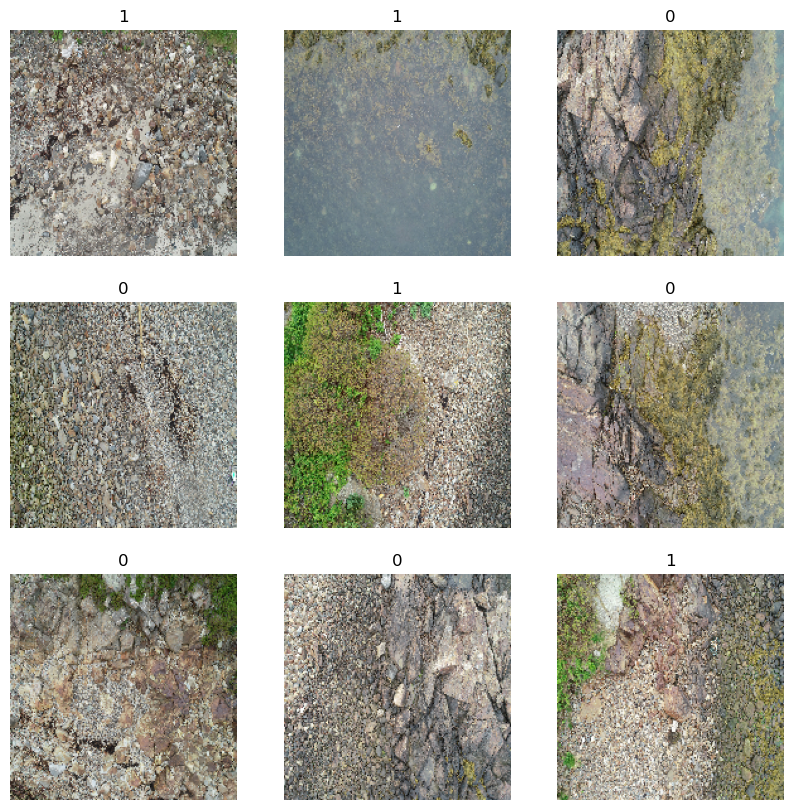

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [5]:
with tf.device('/cpu:0'):
    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.2),
            layers.RandomContrast(0.2),
            layers.RandomBrightness(0.2),
        ]
    )

2023-01-25 13:19:41.523968: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:41.850002: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:42.135344: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:42.432309: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:42.734210: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


...

2023-01-25 13:19:45.352559: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:45.690771: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:45.972519: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:46.252915: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2023-01-25 13:19:46.541260: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


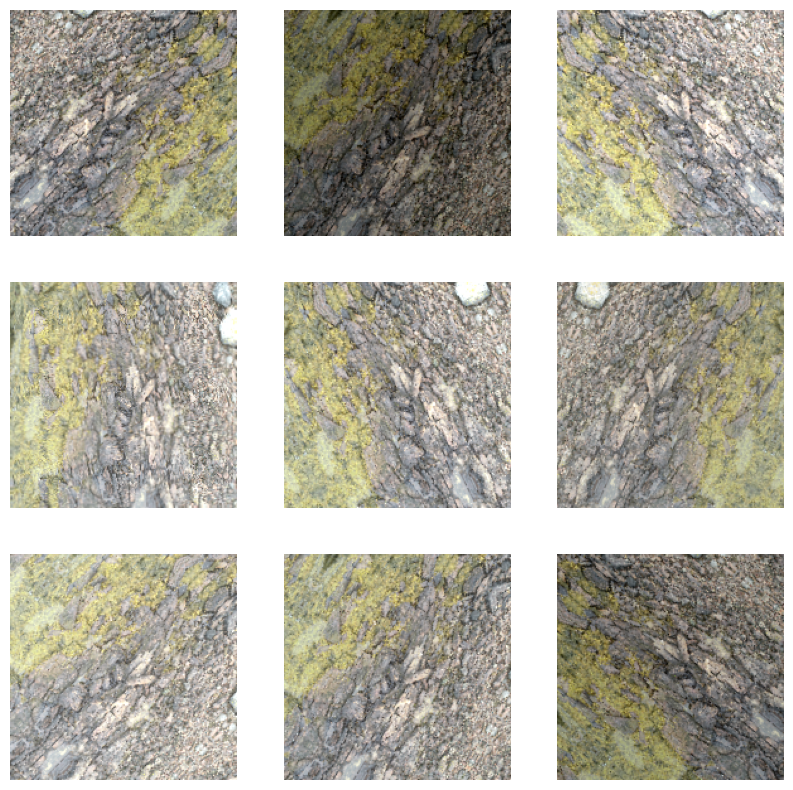

In [6]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")


In [7]:
augmented_train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y))


In [8]:
# Apply `data_augmentation` to the training images.
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf.data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


In [28]:
!pip install keras-tuner --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 2.2 MB/s eta 0:00:00a 0:00:01
  Using cached protobuf-3.19.6-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3


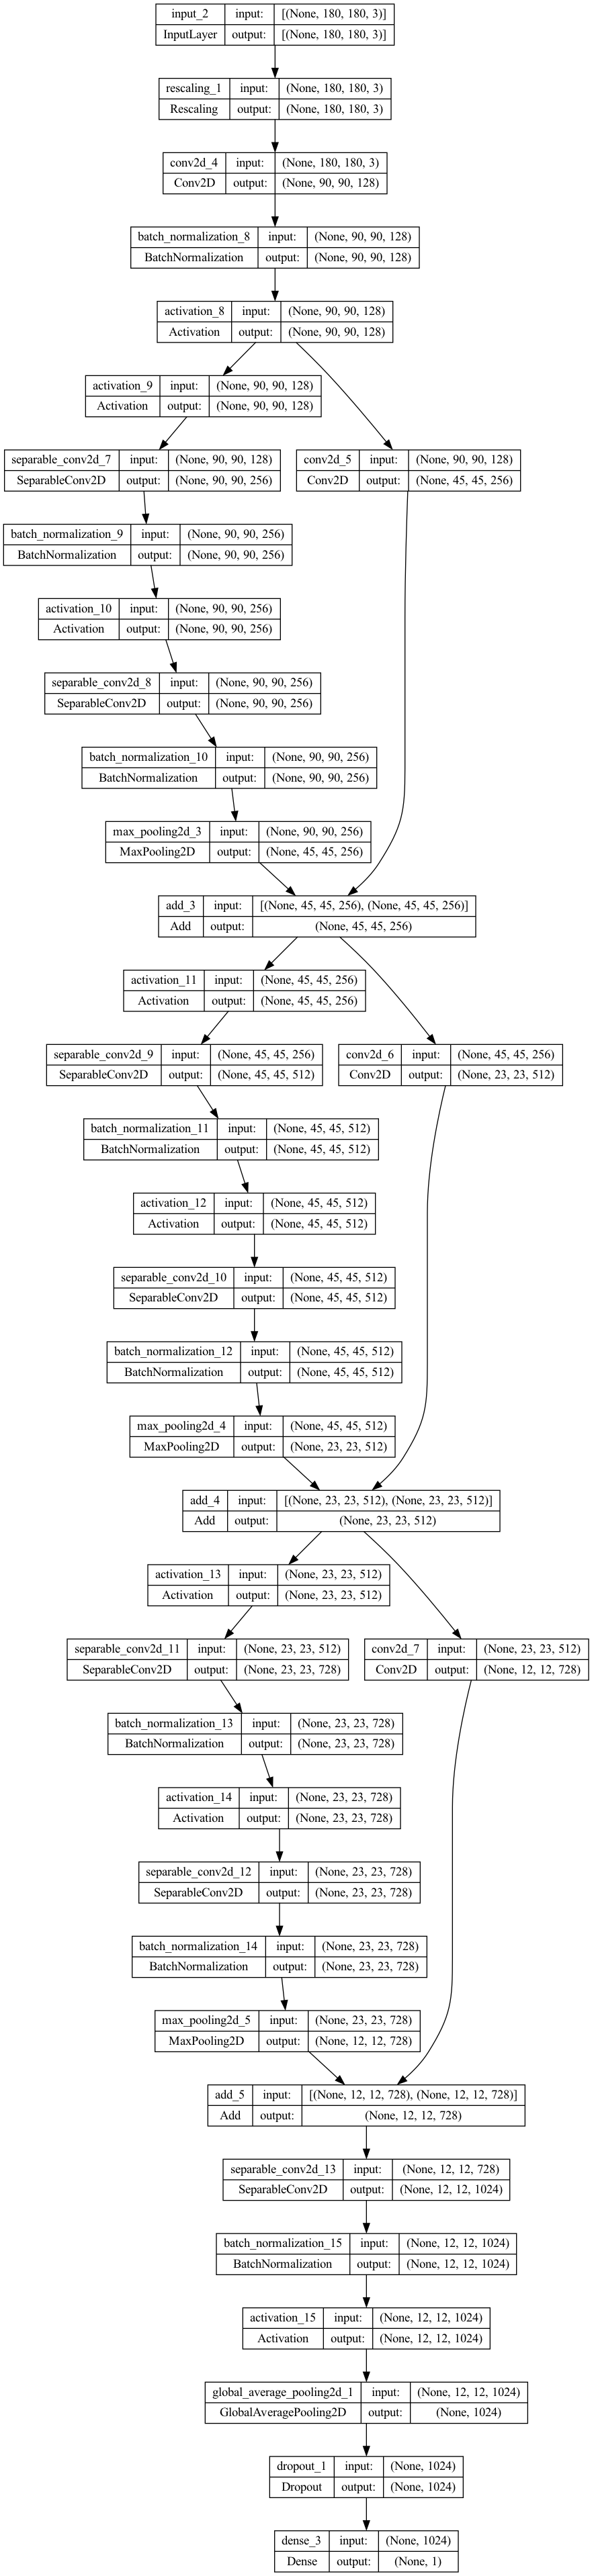

In [33]:
import pydot
import graphviz

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        activation = "sigmoid"
        units = 1
    else:
        activation = "softmax"
        units = num_classes

    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(units, activation=activation)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=2)
keras.utils.plot_model(model, show_shapes=True)


In [47]:
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))


In [48]:
epochs = 5

callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=keras.optimizers.SGD(1e-4),
    loss="BinaryCrossentropy",
    metrics=['acc',f1_m,precision_m, recall_m],
)


In [49]:
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/5


2023-01-25 18:51:56.770181: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


19/19 [==============================] - ETA: 0s - loss: 0.7391 - acc: 0.6497 - f1_m: 0.6453 - precision_m: 0.6254 - recall_m: 0.7129

2023-01-25 18:52:12.143681: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


19/19 [==============================] - 18s 656ms/step - loss: 0.7391 - acc: 0.6497 - f1_m: 0.6453 - precision_m: 0.6254 - recall_m: 0.7129 - val_loss: 0.6588 - val_acc: 0.6829 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 2/5
19/19 [==============================] - 16s 630ms/step - loss: 0.6940 - acc: 0.7075 - f1_m: 0.6928 - precision_m: 0.6733 - recall_m: 0.7352 - val_loss: 0.6541 - val_acc: 0.6829 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 3/5
19/19 [==============================] - 18s 701ms/step - loss: 0.7210 - acc: 0.6701 - f1_m: 0.6442 - precision_m: 0.6298 - recall_m: 0.6894 - val_loss: 0.6492 - val_acc: 0.6829 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 4/5
19/19 [==============================] - 18s 711ms/step - loss: 0.7061 - acc: 0.7143 - f1_m: 0.6994 - precision_m: 0.7147 - recall_m: 0.7128 - val_loss: 0.6446 - val_acc: 0.6829 - val_f1_m: 0.0000

In [51]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 180, 180, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_1 (Rescaling)        (None, 180, 180, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv2d_4 (Conv2D)              (None, 90, 90, 128)  3584        ['rescaling_1[0][0]']            
                                                                                                  
 batch_normalization_8 (BatchNo  (None, 90, 90, 128)  512        ['conv2d_4[0][0]']         

In [50]:
loss, accuracy, f1_score, precision, recall  = model.evaluate(val_ds, verbose=True)


3/3 [==============================] - 2s 131ms/step - loss: 0.6401 - acc: 0.6829 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00


In [26]:
# from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# # From our example of MNIST using Keras 
# # importing sklearn evaluation metrics
# from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, multilabel_confusion_matrix, classification_report
# import numpy as np

import os

for file in os.listdir("test/no_trash"):

    img = keras.preprocessing.image.load_img(
        "test/no_trash/" + file, target_size=image_size
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis

    predictions = model.predict(img_array)
    score = float(predictions[0])
    print(f"This image is {100 * (1 - score):.2f}% trash and {100 * score:.2f}% no trash.")



#print(y_test)
#print(y_pred_bool)

# y_pred = keras.utils.to_categorical(y_pred_bool, num_classes)

# ## confusion matrix
# cm = multilabel_confusion_matrix(y_test1, y_pred)
# print(cm)

# # confusion reports
# report = classification_report(y_test1, y_pred)
# print(classification_report(y_test1, y_pred))


1/1 [==============================] - 0s 11ms/step
This image is 51.30% trash and 48.70% no trash.
1/1 [==============================] - 0s 11ms/step
This image is 51.30% trash and 48.70% no trash.
1/1 [==============================] - 0s 11ms/step
This image is 51.30% trash and 48.70% no trash.
1/1 [==============================] - 0s 11ms/step
This image is 51.30% trash and 48.70% no trash.
1/1 [==============================] - 0s 10ms/step
This image is 51.33% trash and 48.67% no trash.
1/1 [==============================] - 0s 10ms/step
This image is 51.31% trash and 48.69% no trash.
1/1 [==============================] - 0s 11ms/step
This image is 51.29% trash and 48.71% no trash.
1/1 [==============================] - 0s 12ms/step
This image is 51.28% trash and 48.72% no trash.
1/1 [==============================] - 0s 12ms/step
This image is 51.31% trash and 48.69% no trash.
1/1 [==============================] - 0s 13ms/step
This image is 51.30% trash and 48.70% no trash.
